<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/11-Semana/Practica26_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autor: Juan Francisco Gámez Cortés.
Matricula: 261554

Última Modificación: 24 de octubre de 2025

# Práctica #26: Regresión Ridge y Lasso
### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

In [208]:
#Montar google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual

✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  




In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('/content/drive/MyDrive/Unidad03/insurance.csv')
print(df.info())
print("\n")
print(df.head())
print("\n")
print(df.describe())
print("\n")
print(f'Frecuencia de valores únicos Edad:\n',df['age'].value_counts())
print(f'Frecuencia de valores únicos Sexo:\n',df['sex'].value_counts())
print(f'Frecuencia de valores únicos Hijos:\n',df['children'].value_counts())
print(f'Frecuencia de valores únicos Region:\n',df['region'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


               age          bmi     children       charges
count  1338.000000  1338.000

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  




In [210]:
# Estadísticos básicos

#df['children'] = df['children'].astype('category')
# Obtener columnas numéricas
col_numericas = df.select_dtypes(include=['number']).columns.tolist()

print("Estadístos básicos:\n",df[col_numericas].describe())

rango = df[col_numericas].max() - df[col_numericas].min()
moda = df.mode().iloc[0]  # .iloc[0] toma solo el primer valor en caso de múltiples modas
desviacion_est = df[col_numericas].std()
varianza = df[col_numericas].var() #solo variables numericas

# Mostrar el rango de cada columna
print("\nRango de cada columna:")
print(rango)

# Mostrar la moda de cada columna
print("\nModa de cada columna:")
print(moda)
print('\n')

# Desviación estandar
print("Desviación estandar de cada columna:")
print(desviacion_est)
print('\n')

# Mostrar la varianza de cada columna
print("Varianza de cada columna:")
print(varianza)
print('\n')

Estadístos básicos:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Rango de cada columna:
age            46.00000
bmi            37.17000
children        5.00000
charges     62648.55411
dtype: float64

Moda de cada columna:
age                18
sex              male
bmi              32.3
children            0
smoker             no
region      southeast
charges     1639.5631
Name: 0, dtype: object


Desviación estandar de cada columna:
age            14.049960
bmi             6.098187
children        1.205493

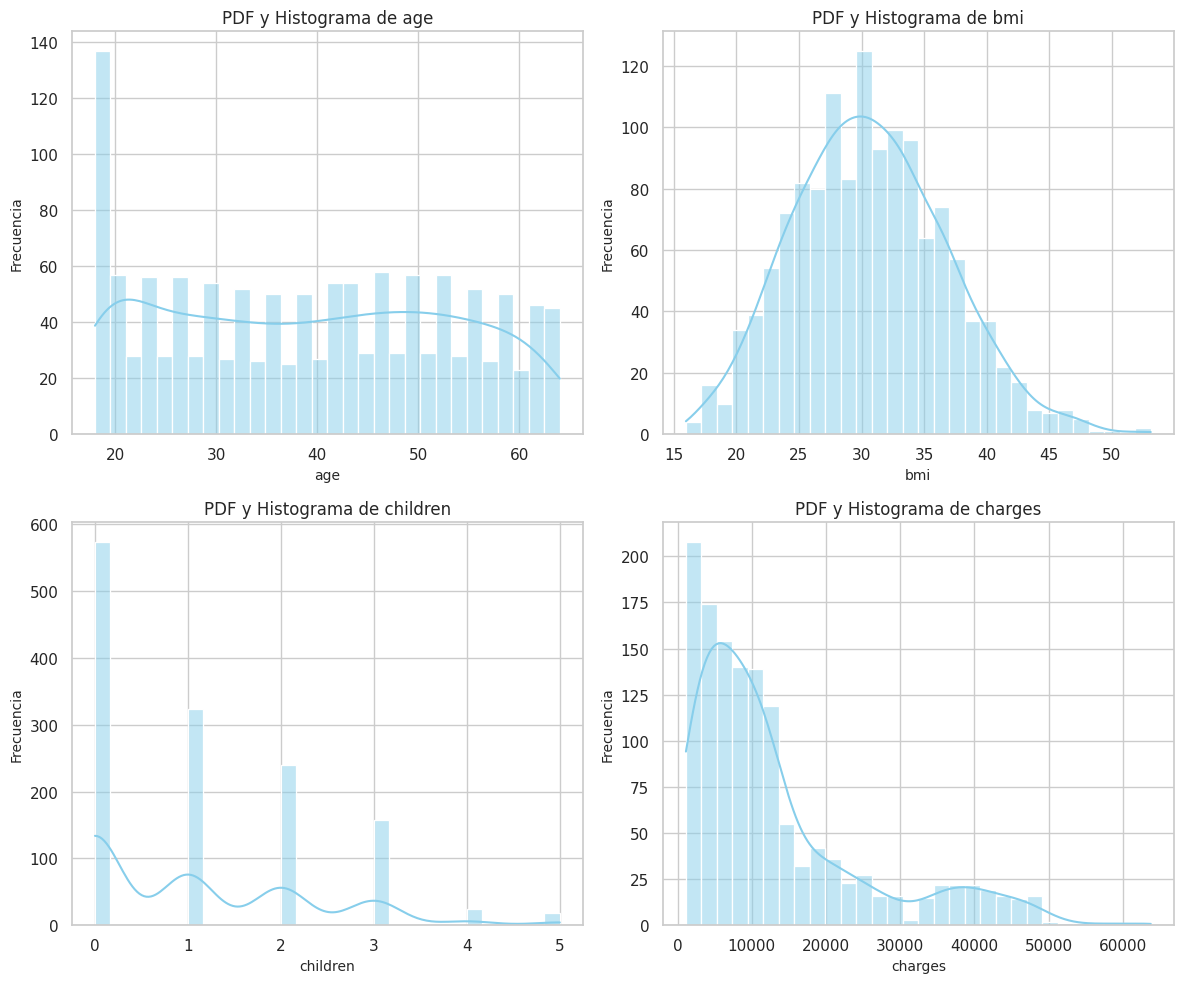

In [211]:
# Crear los gráficos de PDF e Histograma

plt.figure(figsize=(12, 10))
for i, col in enumerate(col_numericas, 1):
    plt.subplot(2, 2, i)  # Ajustar la cantidad de subgráficos según el número de columnas
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'PDF y Histograma de {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frecuencia', fontsize=10)

plt.tight_layout()
plt.show()

Podemos observar lo siguiente:

En el caso de Age, la distribución es similar a la uniforme, tenemos valores de entre 18 y 64 años.

Por su parte el BMI, tiene una distribución en forma de campana de gauss que nos indica una forma normal.

Children tiene una distribución con sesgo a la derecha.

Para Charges, tenemos una distribución con sesgo positivo a la derecha y los valores se concentran entre 0 y 10000 dolares.

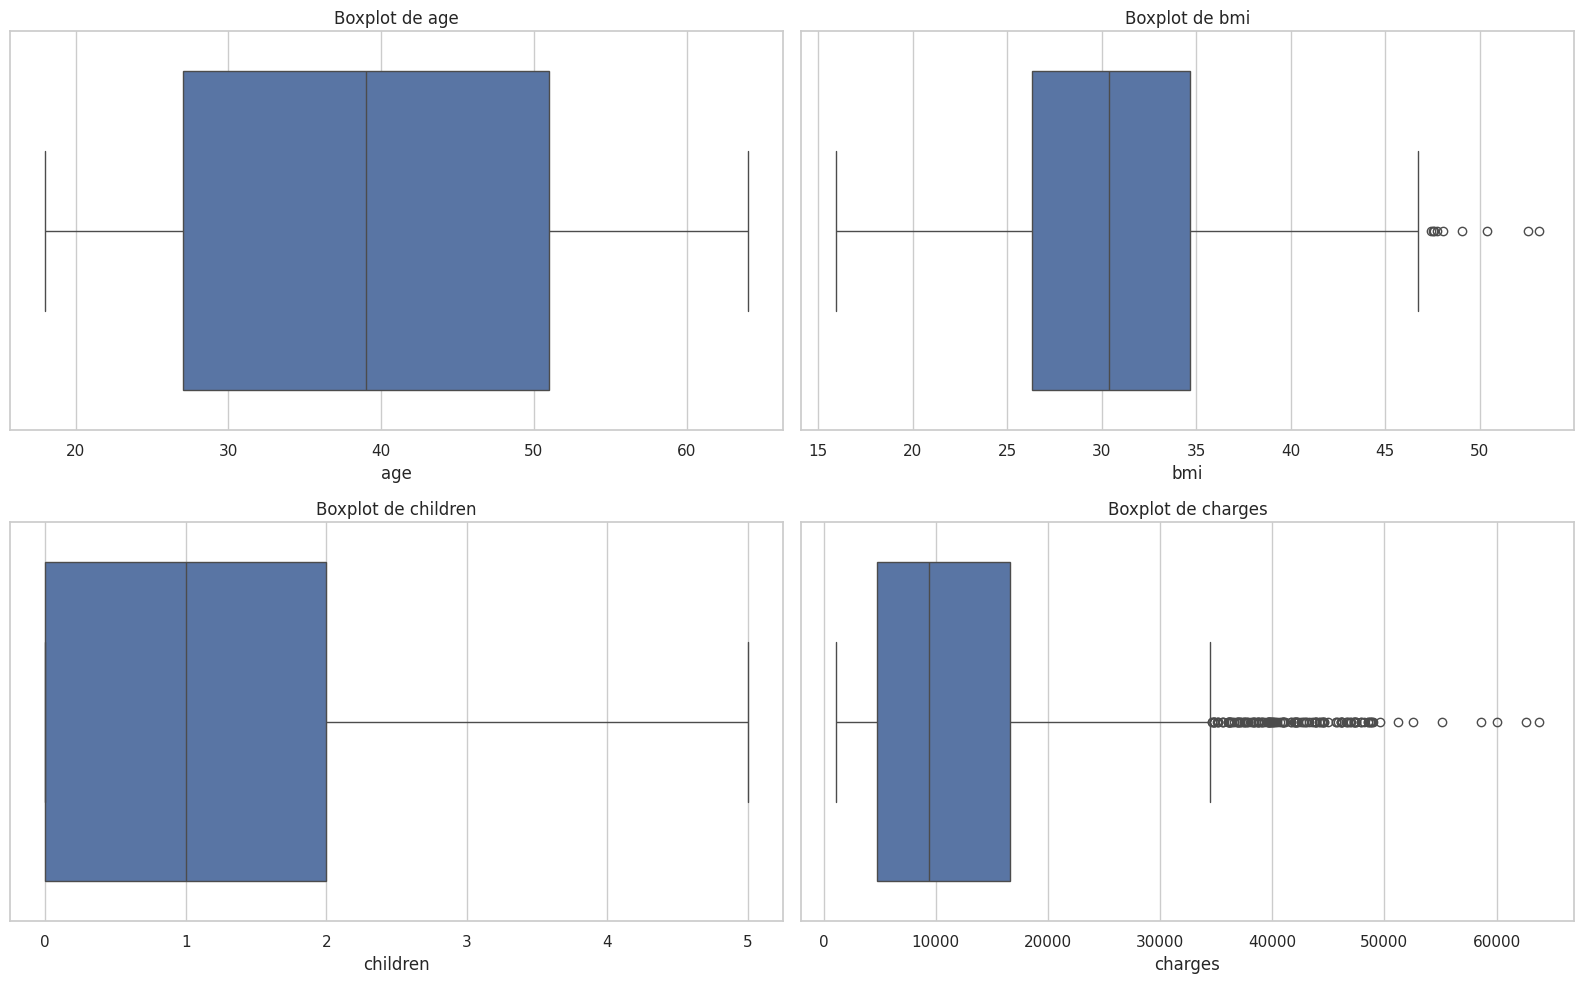

In [212]:
# Configurar el tamaño de la figura
plt.figure(figsize=(16, 10))

# Crear boxplots para cada columna numérica
for i, col in enumerate(col_numericas, 1):
    plt.subplot(2, 2, i)  # 2 filas, 2 columnas de subplots
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()



📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.   

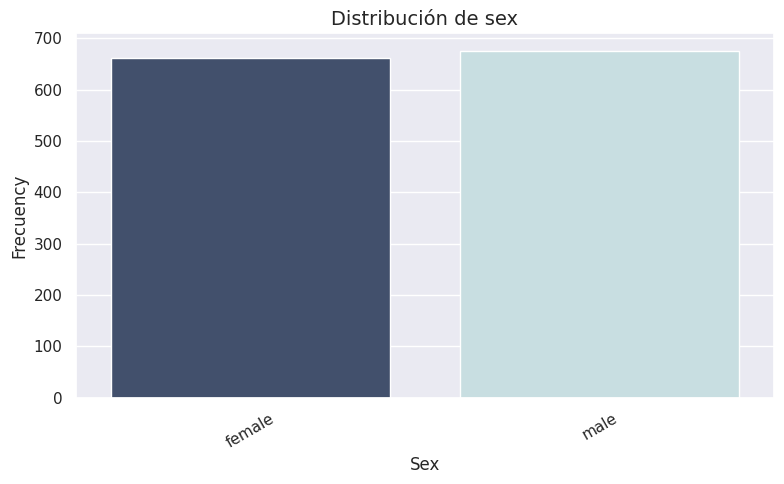

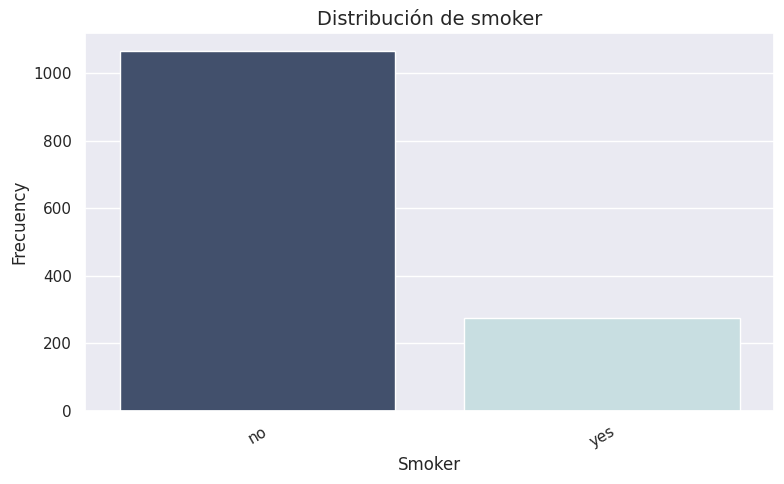

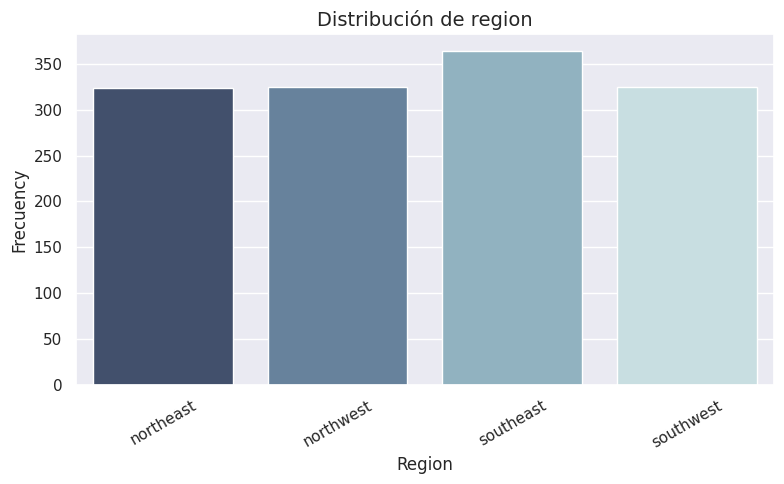

In [213]:
# Obtener columnas categoricas
df['sex'] = df['sex'].astype('category')
#df['children'] = df['children'].astype('category')
df['smoker'] = df['smoker'].astype('category')
df['region'] = df['region'].astype('category')

col_categoricas = df.select_dtypes(include=['category']).columns.tolist()
#print(col_categoricas)

# Crear los gráficos de Barras
sns.set_theme(style="darkgrid")
for col in col_categoricas:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df, hue=col ,legend=False, palette="ch:r=-.2,d=.3_r")
    plt.title(f"Distribución de {col}", fontsize=14)
    plt.xlabel(col.capitalize(), fontsize=12)
    plt.ylabel("Frecuency", fontsize=12)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  



La variable con mayor correlación con el target `charges` es "age" con 0.30. Nos indica que a medida que se incrementa la edad los costos incrementan.



Matriz de correlación:
               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


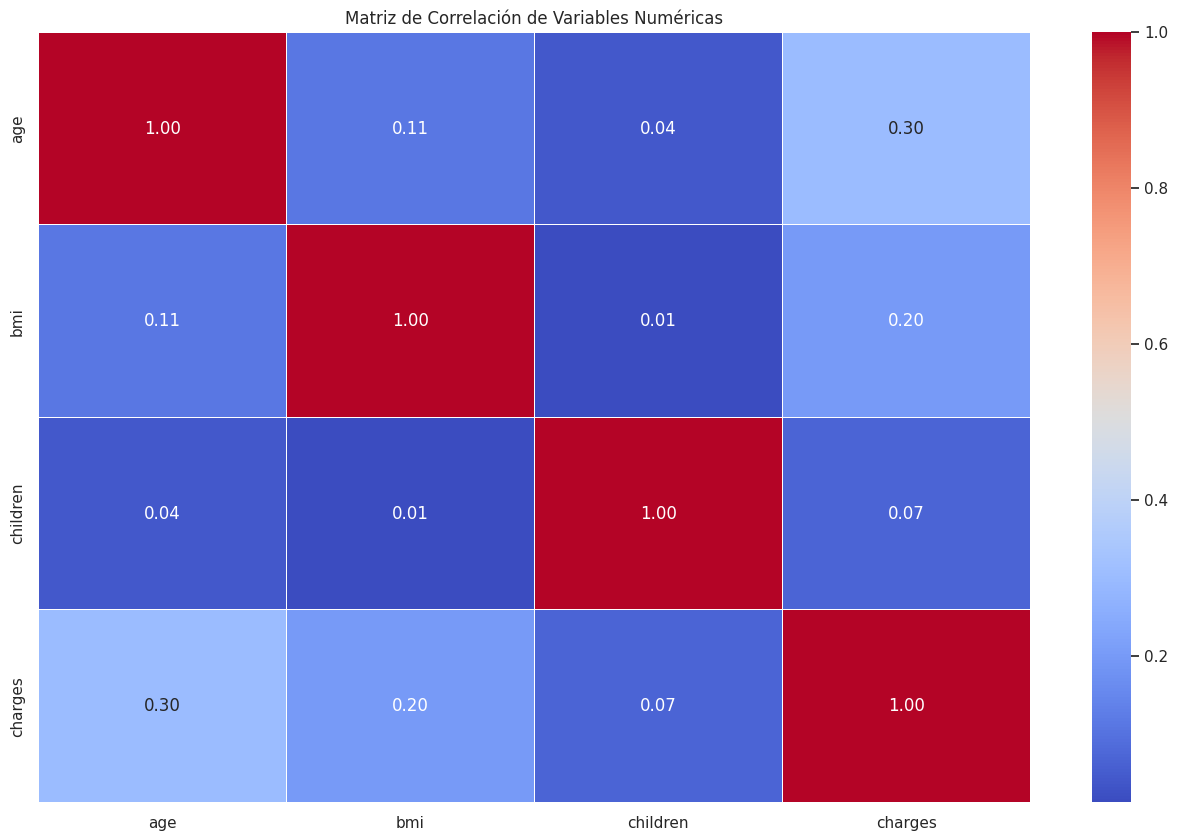

In [214]:
# Seleccionar solo las columnas numéricas
col_numericas = df.select_dtypes(include=[np.number])
#print(col_numericas)

# Calcular la matriz de correlación
corr_matrix = col_numericas.corr()

# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(corr_matrix)

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  



No se identificaron valores perdidos o faltantes, por lo cual no se aplicó `SimpleImputer`

In [215]:
from sklearn.preprocessing import OneHotEncoder

# Verificar valores faltantes
print("Valores faltantes:\n",df.isnull().sum())

# Convertir location a One hot encoding
data = df.copy()

# One hot encoding K-1
print('\n')
print('Versión usando Scikit-Learn: K-1')
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(data[col_categoricas])

# Obtenet el nombre de la columna de interes
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(col_categoricas))

# Combinar con las columnas numéricas originales
final_df = pd.concat([df.drop(columns=col_categoricas), encoded_df], axis=1)

print(encoded_df)

print(final_df)




Valores faltantes:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Versión usando Scikit-Learn: K-1
      sex_male  smoker_yes  region_northwest  region_southeast  \
0          0.0         1.0               0.0               0.0   
1          1.0         0.0               0.0               1.0   
2          1.0         0.0               0.0               1.0   
3          1.0         0.0               1.0               0.0   
4          1.0         0.0               1.0               0.0   
...        ...         ...               ...               ...   
1333       1.0         0.0               1.0               0.0   
1334       0.0         0.0               0.0               0.0   
1335       0.0         0.0               0.0               1.0   
1336       0.0         0.0               0.0               0.0   
1337       0.0         1.0               1.0               0.0   

      region_southwest  
0               

In [216]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Inicializar el StandardScaler
scaler = StandardScaler()


col_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Ajustar y transformar las variables numéricas
scaled_data = scaler.fit_transform(df[col_numericas])

# Crear un DataFrame con las variables estandarizadas
scaled_df = pd.DataFrame(scaled_data, columns=col_numericas)

# Combinar con las variables categóricas originales
df_nuevo = pd.concat([scaled_df, df.drop(columns=col_numericas)], axis=1)

# Mostrar las primeras filas del DataFrame final
print(df_nuevo.head())

# Verificar valores faltantes
print("Valores faltantes:\n",df_nuevo.isnull().sum())

        age       bmi  children   charges     sex smoker     region
0 -1.438764 -0.453320 -0.908614  0.298584  female    yes  southwest
1 -1.509965  0.509621 -0.078767 -0.953689    male     no  southeast
2 -0.797954  0.383307  1.580926 -0.728675    male     no  southeast
3 -0.441948 -1.305531 -0.908614  0.719843    male     no  northwest
4 -0.513149 -0.292556 -0.908614 -0.776802    male     no  northwest
Valores faltantes:
 age         0
bmi         0
children    0
charges     0
sex         0
smoker      0
region      0
dtype: int64


#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  



### Regresión Lasso

In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar el dataset
sns.set(style="whitegrid")

df = pd.read_csv('/content/drive/MyDrive/Unidad03/insurance.csv')

In [218]:
# Seleccionar las características relevantes para el modelo
features = ["age", "sex", "bmi", "children", "smoker", "region"]
target = "charges"
df = df[features + [target]].copy()

In [219]:
# Separar las características en numéricas y categóricas
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi","children"]

In [220]:
# Crear un preprocesador para escalar las variables numéricas y codificar las categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),  # Normaliza las variables numéricas
    ("cat", OneHotEncoder(drop='first'), categorical_features)  # Convierte categóricas a variables dummy
])

In [221]:
# Definir el parámetro de regularización (alpha)
# Se puede ajustar con validación cruzada para optimizar el rendimiento
alpha = 0.1  # Controla la penalización sobre los coeficientes

# Crear un pipeline que primero preprocesa los datos y luego aplica regresión Lasso
lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("lasso", Lasso(alpha=alpha))
])

In [222]:
# Separar las variables predictoras (X) y la variable objetivo (y)
X = df[features]
y = df[target]

#print(X)
#print(y)
# Entrenar el modelo Lasso con los datos
lasso.fit(X, y)

# Obtener los coeficientes después del ajuste
feature_names = numeric_features + list(lasso.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out())
coef = pd.Series(lasso.named_steps["lasso"].coef_, index=feature_names)
print(coef)

age                  3607.401538
bmi                  2067.477362
children              572.886518
sex_male             -130.858174
smoker_yes          23847.874359
region_northwest     -351.296712
region_southeast    -1033.232029
region_southwest     -958.345589
dtype: float64


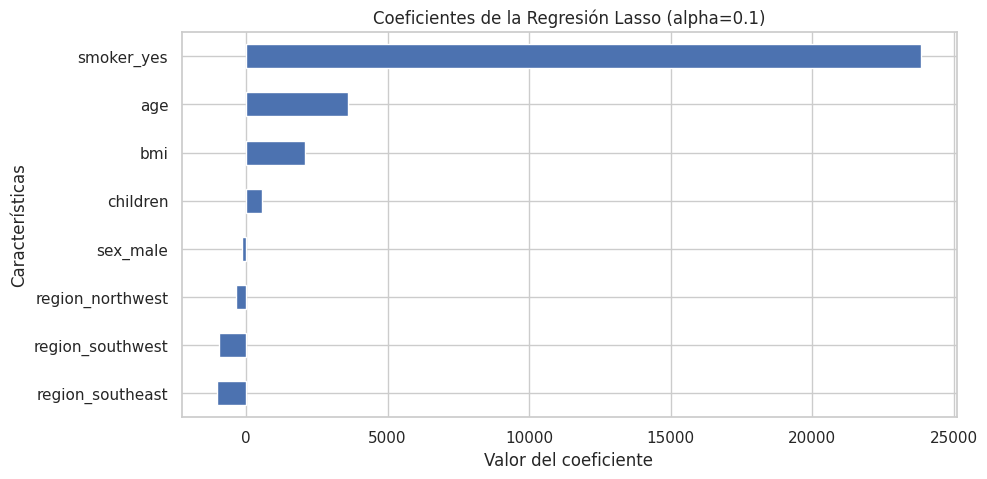

In [223]:
# Graficar los coeficientes de la regresión Lasso
plt.figure(figsize=(10, 5))
coef.sort_values().plot(kind="barh")
plt.title(f"Coeficientes de la Regresión Lasso (alpha={alpha})")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Características")
plt.show()

In [224]:
# Evaluación del modelo con métricas de desempeño
y_pred = lasso.predict(X)
MSE = mean_squared_error(y, y_pred)  # Error cuadrático medio
RMSE = np.sqrt(MSE)  # Raíz del error cuadrático medio
MAE = mean_absolute_error(y, y_pred)  # Error absoluto medio
R2 = r2_score(y, y_pred)  # Coeficiente de determinación
n_nonzero_coef = np.sum(coef != 0)  # Número de coeficientes distintos de cero

In [225]:
# Imprimir los resultados de las métricas
print("Evaluación del modelo Lasso:")
print(f"MSE: {MSE:.2f}")
print(f"RMSE: {RMSE:.2f}")
print(f"MAE: {MAE:.2f}")
print(f"R^2: {R2:.4f}")
print(f"Número de coeficientes no nulos: {n_nonzero_coef}")

Evaluación del modelo Lasso:
MSE: 36501893.68
RMSE: 6041.68
MAE: 4170.90
R^2: 0.7509
Número de coeficientes no nulos: 8


📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?

En este caso tanto Lasso como Ridge tienen valore R² = 75.09. Esto ocurre debido a que ambos modelos identificaron las mismas variables importantes para las predicciones.

- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

Las variables sex_male, region_northwest y children tienen coeficientes cercanos a cero. ESto es debido a que tienen un impacto pequeño o casi insignificante en el modelo

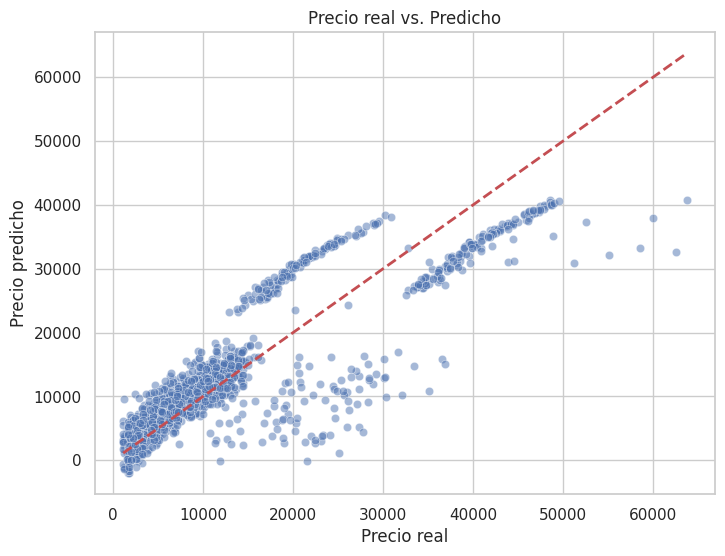

In [226]:
# Gráfico de dispersión: Precio real vs. Predicho
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs. Predicho")
plt.show()

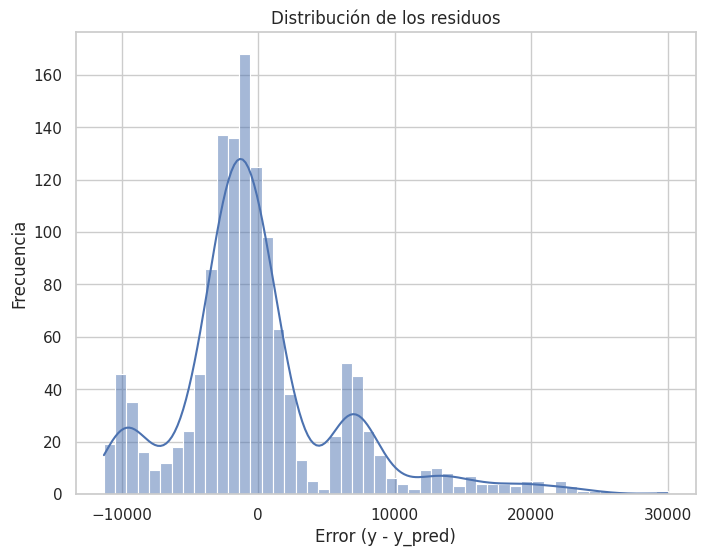

In [227]:
# Histograma de residuos
residuals = y - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()

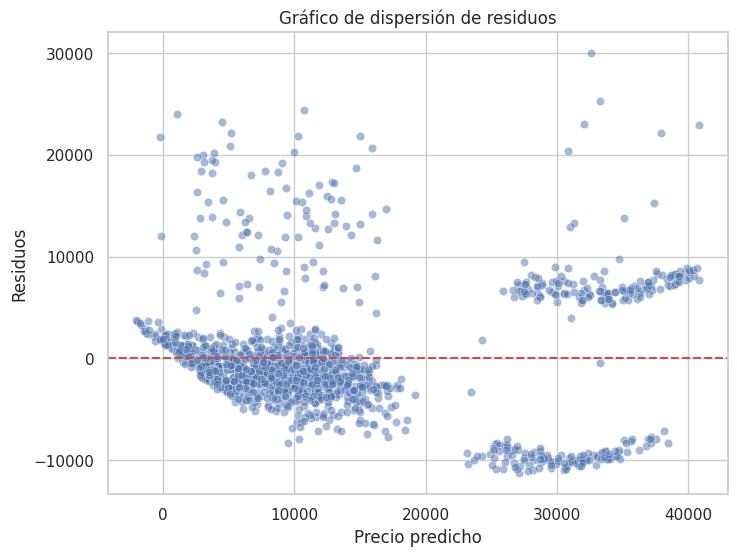

In [228]:
# Gráfico de dispersión de residuos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Gráfico de dispersión de residuos")
plt.show()

#🔵 **Regresión Ridge**

In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar el dataset de diamantes desde seaborn
sns.set(style="whitegrid")

dfR = pd.read_csv('/content/drive/MyDrive/Unidad03/insurance.csv')

In [230]:
# Seleccionar las características relevantes para el modelo
features = ["age", "sex", "bmi", "children", "smoker", "region"]
target = "charges"
dfR = dfR[features + [target]].copy()

In [231]:
# Separar las características en numéricas y categóricas
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi","children"]

In [232]:
# Crear un preprocesador para escalar las variables numéricas y codificar las categóricas
Rpreprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),  # Normaliza las variables numéricas
    ("cat", OneHotEncoder(drop='first'), categorical_features)  # Convierte categóricas a variables dummy
])

# Definir un valor fijo de alpha
Ralpha = 1.0  # Se puede ajustar manualmente según necesidad

# Crear un pipeline con Ridge
ridge = Pipeline([
    ("preprocessor", Rpreprocessor),
    ("ridge", Ridge(alpha=Ralpha))
])

In [233]:
# Separar las variables predictoras (X) y la variable objetivo (y)
X = dfR[features]
y = dfR[target]

# Entrenar el modelo Ridge
ridge.fit(X, y)

# Obtener los coeficientes después del ajuste
feature_names = numeric_features + list(ridge.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out())
Rcoef = pd.Series(ridge.named_steps["ridge"].coef_, index=feature_names)
print(Rcoef)

age                  3604.096982
bmi                  2064.858647
children              573.073125
sex_male             -124.200613
smoker_yes          23737.991359
region_northwest     -347.825073
region_southeast    -1018.540799
region_southwest     -952.384021
dtype: float64


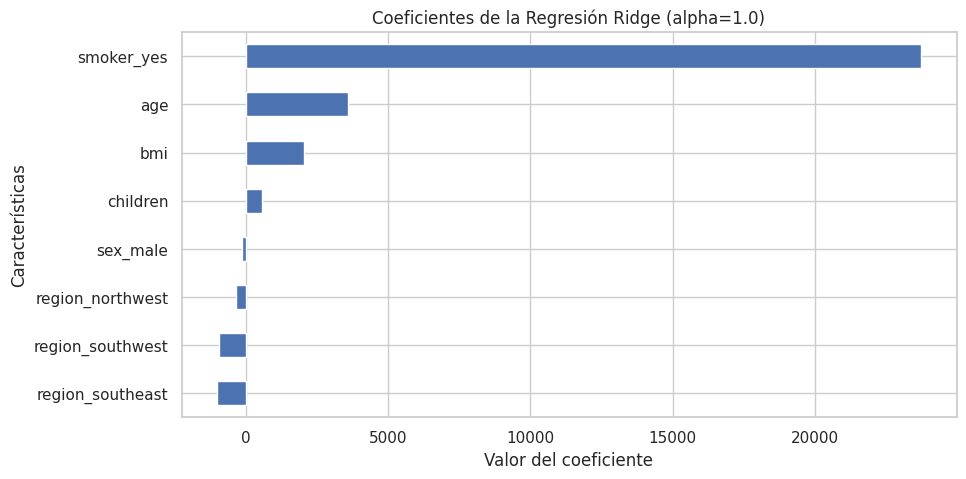

In [234]:
# Graficar los coeficientes de la regresión Ridge
plt.figure(figsize=(10, 5))
Rcoef.sort_values().plot(kind="barh")
plt.title(f"Coeficientes de la Regresión Ridge (alpha={Ralpha})")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Características")
plt.show()

In [235]:
# Evaluación del modelo con métricas de desempeño
Ry_pred = ridge.predict(X)

MSE = mean_squared_error(y, Ry_pred)  # Error cuadrático medio
RMSE = np.sqrt(MSE)  # Raíz del error cuadrático medio
MAE = mean_absolute_error(y, Ry_pred)  # Error absoluto medio
R2 = r2_score(y, Ry_pred)  # Coeficiente de determinación
n_nonzero_coef = np.sum(Rcoef != 0)  # Número de coeficientes distintos de cero

# Imprimir los resultados de las métricas
print("Evaluación del modelo Ridge:")
print(f"MSE: {MSE:.2f}")
print(f"RMSE: {RMSE:.2f}")
print(f"MAE: {MAE:.2f}")
print(f"R^2: {R2:.4f}")
print(f"Número de coeficientes no nulos: {n_nonzero_coef}")


Evaluación del modelo Ridge:
MSE: 36503887.63
RMSE: 6041.84
MAE: 4178.37
R^2: 0.7509
Número de coeficientes no nulos: 8


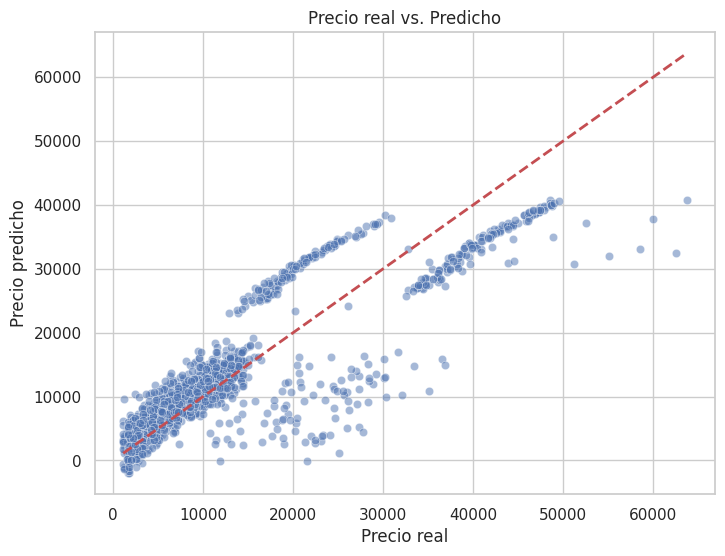

In [236]:
# Gráfico de dispersión: Precio real vs. Predicho
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=Ry_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs. Predicho")
plt.show()

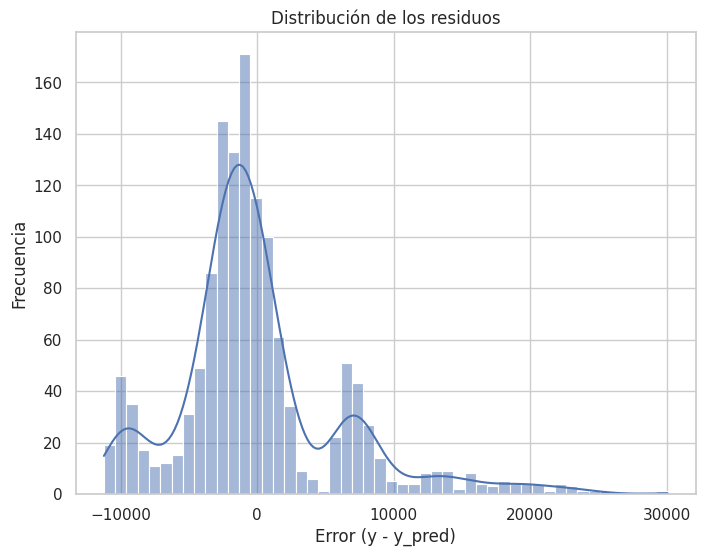

In [237]:
# Histograma de residuos
Rresiduals = y - Ry_pred
plt.figure(figsize=(8, 6))
sns.histplot(Rresiduals, bins=50, kde=True)
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()

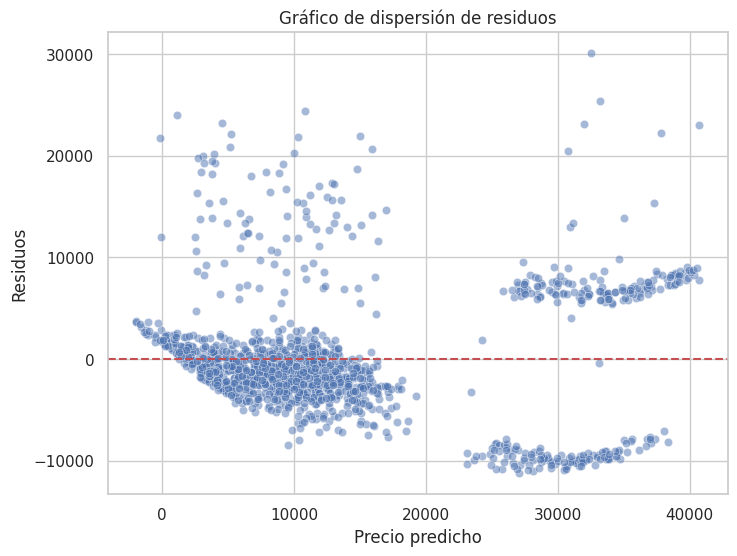

In [238]:
# Gráfico de dispersión de residuos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Ry_pred, y=Rresiduals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Gráfico de dispersión de residuos")
plt.show()

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  




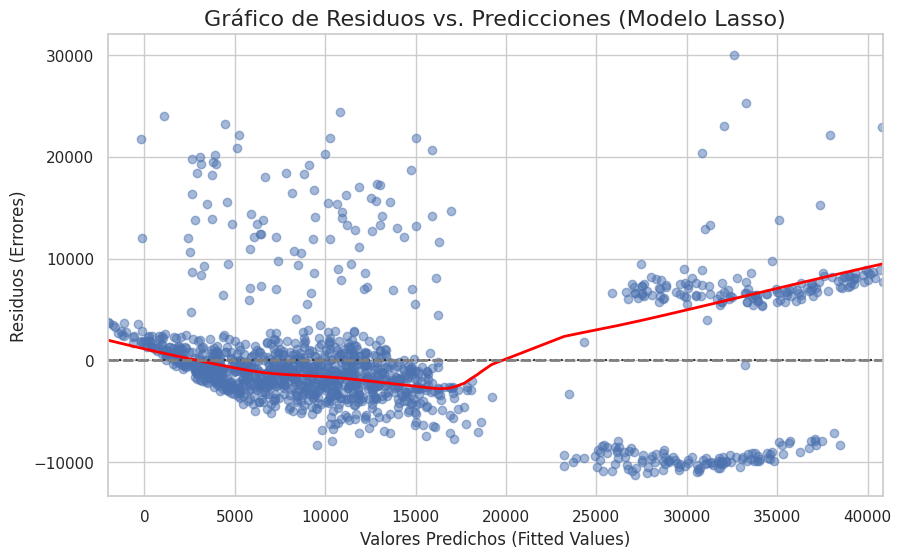

In [239]:
# Creamos el gráfico de Residuos vs. Predicciones
plt.figure(figsize=(10, 6))

sns.residplot(
    x=y_pred,
    y=residuals,
    lowess=True,  # 'lowess=True' dibuja una línea de tendencia que ayuda a ver patrones
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'lw': 2}
)

plt.title('Gráfico de Residuos vs. Predicciones (Modelo Lasso)', fontsize=16)
plt.xlabel('Valores Predichos (Fitted Values)', fontsize=12)
plt.ylabel('Residuos (Errores)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', lw=2) # Añade la línea en y=0
plt.show()

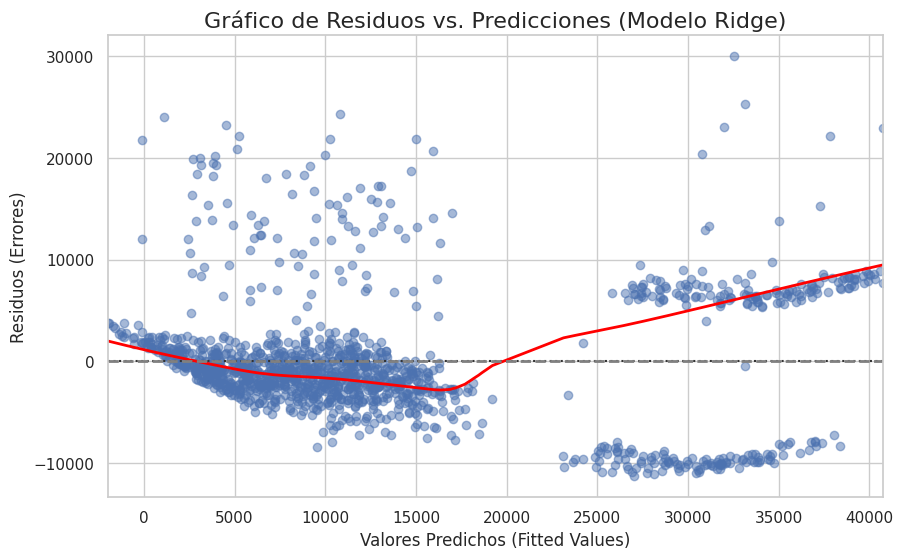

In [240]:
# Creamos el gráfico de Residuos vs. Predicciones
plt.figure(figsize=(10, 6))

sns.residplot(
    x=Ry_pred,
    y=Rresiduals,
    lowess=True,  # 'lowess=True' dibuja una línea de tendencia que ayuda a ver patrones
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'lw': 2}
)

plt.title('Gráfico de Residuos vs. Predicciones (Modelo Ridge)', fontsize=16)
plt.xlabel('Valores Predichos (Fitted Values)', fontsize=12)
plt.ylabel('Residuos (Errores)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', lw=2) # Añade la línea en y=0
plt.show()

2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  


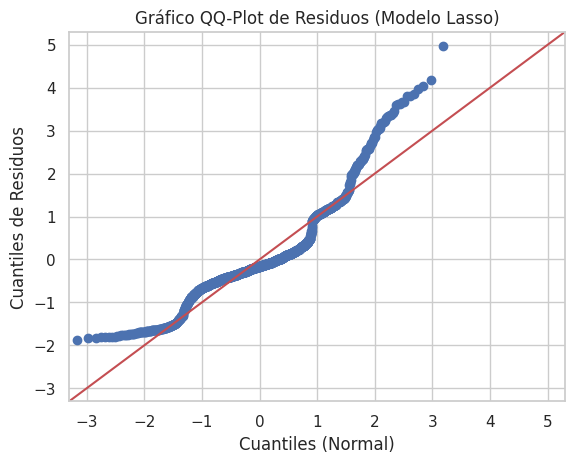


Test Estadístico (Shapiro-Wilk)
Estadístico del Test: 0.8989
P-Value: 8.355430728213068e-29
Intrepretación: (p < 0.05) Los residuos NO parecen ser normales.


In [245]:
import statsmodels.api as sm
from scipy import stats

# Creamos el QQ-Plot
fig = sm.qqplot(residuals, line='45', fit=True)
plt.title('Gráfico QQ-Plot de Residuos (Modelo Lasso)')
plt.xlabel('Cuantiles (Normal)')
plt.ylabel('Cuantiles de Residuos')
plt.show()

# Realizamos el Test de Shapiro-Wilk
print("\nTest Estadístico (Shapiro-Wilk)")
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Estadístico del Test: {shapiro_stat:.4f}")
print(f"P-Value: {shapiro_p}")

# Interpretación del P-Value
if shapiro_p > 0.05:
    print("Intrepretación: (p > 0.05) Los residuos parecen ser normales.")
else:
    print("Intrepretación: (p < 0.05) Los residuos NO parecen ser normales.")

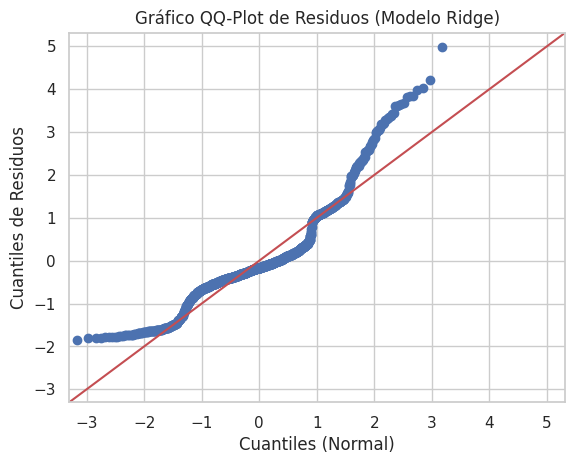


Test Estadístico (Shapiro-Wilk)
Estadístico del Test: 0.8980
P-Value: 6.458843138896771e-29
Intrepretación: (p < 0.05) Los residuos NO parecen ser normales.


In [246]:
import statsmodels.api as sm
from scipy import stats

# Creamos el QQ-Plot
fig = sm.qqplot(Rresiduals, line='45', fit=True)
plt.title('Gráfico QQ-Plot de Residuos (Modelo Ridge)')
plt.xlabel('Cuantiles (Normal)')
plt.ylabel('Cuantiles de Residuos')
plt.show()

# Realizamos el Test de Shapiro-Wilk
print("\nTest Estadístico (Shapiro-Wilk)")
shapiro_stat, shapiro_p = stats.shapiro(Rresiduals)

print(f"Estadístico del Test: {shapiro_stat:.4f}")
print(f"P-Value: {shapiro_p}")

# Interpretación del P-Value
if shapiro_p > 0.05:
    print("Intrepretación: (p > 0.05) Los residuos parecen ser normales.")
else:
    print("Intrepretación: (p < 0.05) Los residuos NO parecen ser normales.")

3. **Homocedasticidad** (test de Breusch-Pagan).  


In [258]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge # Import Ridge

# Cargar el dataset
sns.set(style="whitegrid")

df = pd.read_csv('/content/drive/MyDrive/Unidad03/insurance.csv')

# Seleccionar las características relevantes para el modelo
features = ["age", "sex", "bmi", "children", "smoker", "region"]
target = "charges"
df = df[features + [target]].copy()

# Separar las características en numéricas y categóricas
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi","children"]

# Crear un preprocesador para escalar las variables numéricas y codificar las categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),  # Normaliza las variables numéricas
    ("cat", OneHotEncoder(drop='first'), categorical_features)  # Convierte categóricas a variables dummy
])

# Definir el parámetro de regularización (alpha)
# Se puede ajustar con validación cruzada para optimizar el rendimiento
alpha = 0.1  # Controla la penalización sobre los coeficientes

# Crear un pipeline que primero preprocesa los datos y luego aplica regresión Lasso
lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("lasso", Lasso(alpha=alpha))
])

# Separar las variables predictoras (X) y la variable objetivo (y)
X = df[features]
y = df[target]

# Entrenar el modelo Lasso con los datos
lasso.fit(X, y)

y_pred = lasso.predict(X)

# Calculate residuals for the Ridge model
residuals = y - y_pred


# Apply the preprocessor to X to get the processed features for the test
X_processed = preprocessor.transform(X)

# Convert the processed array back to a DataFrame for easier handling and adding constant
# Get the names of the processed columns
processed_feature_names = numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)

# Add a constant term to the processed features
X_train_with_const = sm.add_constant(X_processed_df, prepend=False)

print("\nTest Estadístico (Breusch-Pagan) Modelo Lasso")
# Use the residuals calculated from the Ridge model in this cell
bp_test = het_breuschpagan(Rresiduals, X_train_with_const)


print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"P-Value (del LM): {bp_test[1]}")
print(f"Estadístico F: {bp_test[2]:.4f}")
print(f"P-Value (del F): {bp_test[3]}")

# Interpretación del P-Value (usamos el p-value del LM)
p_value = bp_test[1]
if p_value > 0.05:
    print("\nConclusión: (p > 0.05) Los residuos parecen ser homocedásticos.")
else:
    print("\nConclusión: (p < 0.05) Los residuos NO son homocedásticos (Heteroscedasticidad detectada).")


Test Estadístico (Breusch-Pagan) Modelo Lasso
Estadístico LM: 122.2240
P-Value (del LM): 1.1511217628166075e-22
Estadístico F: 16.7008
P-Value (del F): 8.914168756324357e-24

Conclusión: (p < 0.05) Los residuos NO son homocedásticos (Heteroscedasticidad detectada).


4. **Multicolinealidad Lasso** (VIF > 10 indica problema).  

In [264]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF
X_processed_with_const = sm.add_constant(X_processed_df, prepend=False)

vif_data = pd.DataFrame()
vif_data["feature"] = X_processed_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_processed_with_const.values, i)
                   for i in range(X_processed_with_const.shape[1])]

print("VIF:")
print(vif_data)

VIF:
            feature       VIF
0               age  1.016822
1               bmi  1.106630
2          children  1.004011
3          sex_male  1.008900
4        smoker_yes  1.012074
5  region_northwest  1.518823
6  region_southeast  1.652230
7  region_southwest  1.529411
8             const  5.428992


In [265]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge # Import Ridge

# Cargar el dataset
sns.set(style="whitegrid")

dfR = pd.read_csv('/content/drive/MyDrive/Unidad03/insurance.csv')

# Seleccion de features
features = ["age", "sex", "bmi", "children", "smoker", "region"]
target = "charges"
X = dfR[features]
y = dfR[target]

# Separación de features
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi","children"]

# Preprocesador
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop='first'), categorical_features)
])

# Definir alpha para modelo Ridge
Ralpha = 1.0
ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=Ralpha))
])

# Fit the Ridge model
ridge.fit(X, y)

Ry_pred = ridge.predict(X)

# Calculate residuals for the Ridge model
Rresiduals = y - Ry_pred


# Apply the preprocessor to X to get the processed features for the test
X_processed = preprocessor.transform(X)

# Convert the processed array back to a DataFrame for easier handling and adding constant
# Get the names of the processed columns
processed_feature_names = numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)

# Add a constant term to the processed features
X_train_with_const = sm.add_constant(X_processed_df, prepend=False)

print("\nTest Estadístico (Breusch-Pagan) Modelo Ridge")
# Use the residuals calculated from the Ridge model in this cell
bp_test = het_breuschpagan(Rresiduals, X_train_with_const)


print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"P-Value (del LM): {bp_test[1]}")
print(f"Estadístico F: {bp_test[2]:.4f}")
print(f"P-Value (del F): {bp_test[3]}")

# Interpretación del P-Value (usamos el p-value del LM)
p_value = bp_test[1]
if p_value > 0.05:
    print("\nConclusión: (p > 0.05) Los residuos parecen ser homocedásticos.")
else:
    print("\nConclusión: (p < 0.05) Los residuos NO son homocedásticos (Heteroscedasticidad detectada).")


Test Estadístico (Breusch-Pagan) Modelo Ridge
Estadístico LM: 122.2240
P-Value (del LM): 1.1511217628166075e-22
Estadístico F: 16.7008
P-Value (del F): 8.914168756324357e-24

Conclusión: (p < 0.05) Los residuos NO son homocedásticos (Heteroscedasticidad detectada).


4. **Multicolinealidad Ridge** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?

No se cumplen los supuestos para ambos modelos

- Si hay heterocedasticidad, ¿cómo podría solucionarse?

Se puede solucionar transformando la variable charges con logaritmo y posteriormente entrenar los modelos o en su caso usar otros modelos como Random Forest Regressor o XGBoost

In [266]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF
X_processed_with_const = sm.add_constant(X_processed_df, prepend=False)

vif_data = pd.DataFrame()
vif_data["feature"] = X_processed_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_processed_with_const.values, i)
                   for i in range(X_processed_with_const.shape[1])]

print("VIF:")
print(vif_data)

VIF:
            feature       VIF
0               age  1.016822
1               bmi  1.106630
2          children  1.004011
3          sex_male  1.008900
4        smoker_yes  1.012074
5  region_northwest  1.518823
6  region_southeast  1.652230
7  region_southwest  1.529411
8             const  5.428992


#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
En este caso los dos modelos resultan igualmente interpretables, derivado que los modelos se comportan muy similares para las variables del dataset

- ¿Cuál reduce mejor el sobreajuste?  
Ambos se comportan similar, por lo cual podemos elegir cualquiera

- ¿Qué variables son más importantes en cada caso?  
Las variables son iguales en importancia para cada caso.
---


### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.